# **Modelling**   

### Tree classifier Models with Grid search

## Objectives

* Build and evaluate baseline classification models that predict hazardous status using geometric and orbital features (diameter, miss_distance, relative_velocity, absolute_magnitude, observations).

## Inputs

* `features_model.csv` 


## Outputs

* Trained baseline models: Random Forest, Decision Trees, Extra Trees Classifiers XGBoost.
* Evaluation artifacts: cross-validated metrics (ROC-AUC, PR-AUC), confusion matrices, calibration plots, feature importance (coefficients/SHAP).
* Results table comparing models.
* Plots of confusion matrices, comparison and interplay of most important features.


## Success Criteria

* Reproducible pipeline: running the notebook top-to-bottom recreates models and metrics.
* At least one model achieves ROC-AUC > 0.70 (adjust threshold if class imbalance makes this infeasible); or shows improvement over a baseline (random or constant classifier).
* At least one model has at least 70% recall (correct identification of hazardous asteroids)
* Models are interpretable: Showing feature importances, accuracy of models and validation/ rejection of hypotheses.

**Note**: *I have included commented out code in GridSearch section with a more limited set of parameters for convenience and to aid reproducibility - the current, uncommented, code has a long run time*


---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\mikee\\Desktop\\Near-Earth-Asteroid-Analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chdir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\mikee\\Desktop\\Near-Earth-Asteroid-Analysis'

# ML - Tree Models

Import Libraries

In [4]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### Objective
* Predict if an asteroid is hazardous based on physical/ orbital properties.
* Target variable `hazardous_enc`

#### Workflow
* Load Data
* Select Features for training
* Split Train and Test Data
* Create Pipeline - Encode categorical data (label encoding)
* Train Tree Based Models
* Analyse Results
* Check feature importance 
* Visualise important features 


#### Load Data

In [5]:
#load feature_models.csv
df_model = pd.read_csv('Data/Processed/features_model.csv')
df_model.head(4).T

,0,1,2,3
name,(1983 LC),(1986 NA),(1988 NE),(1989 AZ)
est_diameter_min,0.342417,0.28481,0.402305,0.319562
est_diameter_max,0.765667,0.636854,0.89958,0.714562
relative_velocity_mean,60192.646491,51810.077045,22815.738845,55184.046572
miss_distance_mean,18476643.271,70052459.208572,65063306.320902,25604655.93738
miss_distance_min,10334476.5074,70052459.208572,65063306.320902,20219801.806052
absolute_magnitude_mean,19.45,19.85,19.1,19.6
hazardous,True,False,False,False
observations,2,1,1,2
est_diameter_range,0.42325,0.352044,0.497276,0.395


In [6]:
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
est_diameter_min,10155.0,3.216389e-01,5.700167e-01,0.086807,1.332156e-01,2.111324e-01,3.544509e-01,3.789265e+01
est_diameter_max,10155.0,7.192066e-01,1.274596e+00,0.194106,2.978791e-01,4.721065e-01,7.925764e-01,8.473054e+01
relative_velocity_mean,10155.0,5.687184e+04,2.765598e+04,646.320239,3.743231e+04,5.503513e+04,7.367590e+04,2.282422e+05
miss_distance_mean,10155.0,4.285755e+07,1.483938e+07,832144.928659,3.388199e+07,4.407155e+07,5.305426e+07,7.479865e+07
miss_distance_min,10155.0,3.201981e+07,1.776006e+07,143272.707499,1.757402e+07,3.029674e+07,4.454890e+07,7.479865e+07
absolute_magnitude_mean,10155.0,2.027937e+01,1.526651e+00,9.230000,1.937500e+01,2.050000e+01,2.150000e+01,2.243000e+01
observations,10155.0,3.260266e+00,3.135806e+00,1.000000,1.000000e+00,2.000000e+00,4.000000e+00,4.300000e+01
est_diameter_range,10155.0,3.975676e-01,7.045794e-01,0.107299,1.646635e-01,2.609741e-01,4.381255e-01,4.683789e+01
est_diameter_mean,10155.0,5.204227e-01,9.223064e-01,0.140457,2.155473e-01,3.416195e-01,5.735137e-01,6.131160e+01
est_diameter_min_log1p,10155.0,2.519293e-01,1.988458e-01,0.083244,1.250592e-01,1.915558e-01,3.033960e-01,3.660805e+00


In [7]:
df_model.shape

(10155, 24)

### Select Features

For our tree based model we will select only categorical features (to be encoded) and raw data features.
`log1p` based features, `name` and `hazardous` (as we also have `hazadardous_enc`) will be dropped.

List of features to be included:
* feature_cols = [
    `est_diameter_mean`, `miss_distance_mean`, `relative_velocity_mean`,
    `absolute_magnitude_mean`, `observations`,
    `diameter_class`, `proximity_class`, `velocity_class`, `brightness_class`, `observation_class`
]
* target_col = `hazardous_enc`

Justification:
Log values are not needed for tree models. Keeping categorical and continuous feature will lead to some duplication of data, but should be pruned by feature importance test.

### Encoding Data

* Features to be encoded
    * `diameter_class`
    * `proximity_class`
    * `velocity_class`
    * `brightness_class`
    * `observation_class`

In [8]:
# Define features and target
feature_cols = [
    "est_diameter_mean", "miss_distance_mean", "relative_velocity_mean",
    "absolute_magnitude_mean", "observations",
    "diameter_class", "proximity_class", "velocity_class", "brightness_class", "observation_class"
]
df_tree_model = df_model[feature_cols + ['hazardous_enc']].copy()
df_tree_model.head(3).T

,0,1,2
est_diameter_mean,0.554042,0.460832,0.650942
miss_distance_mean,18476643.271,70052459.208572,65063306.320902
relative_velocity_mean,60192.646491,51810.077045,22815.738845
absolute_magnitude_mean,19.45,19.85,19.1
observations,2,1,1
diameter_class,medium,small,medium
proximity_class,medium,very_distant,very_distant
velocity_class,moderate,slow,slow
brightness_class,dim,dim,dim
observation_class,few,single,single


Create Train & Test Sets

In [9]:
#split the dataset into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_tree_model[feature_cols], df_tree_model['hazardous_enc'], test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8124, 10), (2031, 10), (8124,), (2031,))

In [10]:
#Check target class distribution in train and test sets
print("Class balance (train):", y_train.value_counts(normalize=True).to_dict())
print("Class balance (test):", y_test.value_counts(normalize=True).to_dict())

Class balance (train): {0: 0.7865583456425406, 1: 0.21344165435745938}
Class balance (test): {0: 0.7838503200393895, 1: 0.21614967996061055}


Our Train and test groups have a good balance for our target class.

Next step is to create our pipeline - we will test several Tree Models simultaneously to see which perform best.

I will use RandomForestClassifier,DecisionTreeClassifier and ExtraTreesClassifier as my initial models - depending on results I will test other Tree Models to see which performs best.

In [11]:
from sklearn.pipeline import Pipeline
from feature_engine.imputation import MeanMedianImputer, CategoricalImputer
from feature_engine.encoding import OrdinalEncoder
from sklearn.feature_selection import SelectFromModel

# Define feature groups so the pipeline knows what to touch
NUMERIC_VARS = [
    "est_diameter_mean", "miss_distance_mean", "relative_velocity_mean",
    "absolute_magnitude_mean", "observations"
]
ORDINAL_VARS = [
    "diameter_class", "proximity_class", "velocity_class",
    "brightness_class", "observation_class"
]
# Create a function that builds a pipeline with a given model
# No scaling needed for tree-based models
def PipelineOptimization(model):
    pipeline_base = Pipeline(steps=[
        # 1) Impute numeric (median is robust to skew)
        ("num_imputer", MeanMedianImputer(imputation_method="median", variables=NUMERIC_VARS)),

        # 2) Impute categoricals (mode/most frequent)
        ("cat_imputer", CategoricalImputer(imputation_method="frequent", variables=ORDINAL_VARS)),

        # 3) Ordinal-encode ordered categories (keeps rank meaning for trees)
        ("ord_encoder", OrdinalEncoder(encoding_method="arbitrary", variables=ORDINAL_VARS)),

        # 4) Feature selection from model (uses model’s importances)
        ("feat_selection", SelectFromModel(model)),

        # 5) Final estimator
        ("model", model),
    ])
    return pipeline_base


Our next step is to define our candidate tree models to test

In [12]:
# Define candidate models to test first import the models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
#define the candidates
candidates = {
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
}

Next we create a testing loop for our models

In [13]:
# --- Train & evaluate loop ---
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, classification_report
# Create empty lists to store results
results = []
reports = {}
# Loop through candidates
for name, model in candidates.items():
    pipe = PipelineOptimization(model)
    pipe.fit(X_train, y_train)

    # Predict on test set
    y_prob = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None
    y_pred = pipe.predict(X_test)

    # Evaluate metrics
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    pr  = average_precision_score(y_test, y_prob) if y_prob is not None else np.nan

    # Store results
    results.append({"model": name, "accuracy": acc, "roc_auc": roc, "pr_auc": pr})
    reports[name] = classification_report(y_test, y_pred, digits=3)

# Show summary table
results_df = pd.DataFrame(results).sort_values(by=["pr_auc","roc_auc","accuracy"], ascending=False)
results_df
#

# Print concise reports
for name, rpt in reports.items():
    print(f"\n=== {name} ===")
    print(rpt)


=== DecisionTree ===
              precision    recall  f1-score   support

           0      0.832     0.818     0.825      1592
           1      0.378     0.401     0.389       439

    accuracy                          0.728      2031
   macro avg      0.605     0.610     0.607      2031
weighted avg      0.734     0.728     0.731      2031


=== RandomForest ===
              precision    recall  f1-score   support

           0      0.822     0.916     0.867      1592
           1      0.481     0.282     0.356       439

    accuracy                          0.779      2031
   macro avg      0.651     0.599     0.611      2031
weighted avg      0.748     0.779     0.756      2031


=== ExtraTrees ===
              precision    recall  f1-score   support

           0      0.820     0.910     0.863      1592
           1      0.460     0.278     0.347       439

    accuracy                          0.774      2031
   macro avg      0.640     0.594     0.605      2031
weighted a

All 3 models had reasonable recall for True Negative, but had relatively poor recall for true Negative. Random Forest was the best overall in terms of precision and accuracy - see below.


Confusion Matrix for RandomForest:
True Negatives : 1458
False Positives: 134
False Negatives: 315
True Positives : 124
True Negatives : 1458
False Positives: 134
False Negatives: 315
True Positives : 124


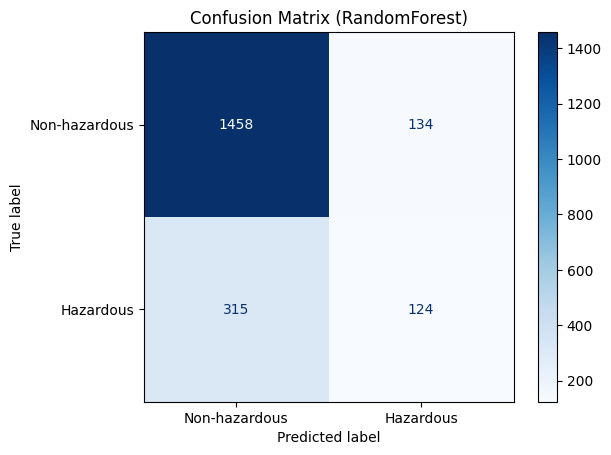

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# display for your best model (or inside the loop)
best_model_name = results_df.iloc[0]["model"]
print(f"\nConfusion Matrix for {best_model_name}:")

# Refit best pipeline if needed
best_model = candidates[best_model_name]
best_pipe = PipelineOptimization(best_model)
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)


# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Print absolute values
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

# Display confusion matrix for best model (RandomForest)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-hazardous", "Hazardous"])
disp.plot(cmap="Blues", values_format="d")
disp.ax_.set_title(f"Confusion Matrix ({best_model_name})")
plt.show()


Although this was the best model, recall of less than 30% is quite disappointing.
The next step is to look at grid search to tune parameters.

### Grid Search

We will use Grid Search to find better hyper-parameters for our models. We will also refine our metrics to weight more for True Positives (i.e. correctly predicting for Hazardous Asteroids)


>>> Tuning DecisionTree ...
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits

Best CV recall: 0.822
Best params: {'feat_selection__max_features': None, 'feat_selection__threshold': 'mean', 'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 8, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10}

Test classification report:
              precision    recall  f1-score   support

           0      0.924     0.572     0.706      1592
           1      0.348     0.829     0.490       439

    accuracy                          0.627      2031
   macro avg      0.636     0.700     0.598      2031
weighted avg      0.799     0.627     0.660      2031

TN:910 FP:682 FN:75 TP:364

Best CV recall: 0.822
Best params: {'feat_selection__max_features': None, 'feat_selection__threshold': 'mean', 'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 8, 'model__min_samples_leaf': 2, 'model__min_samples_split': 1

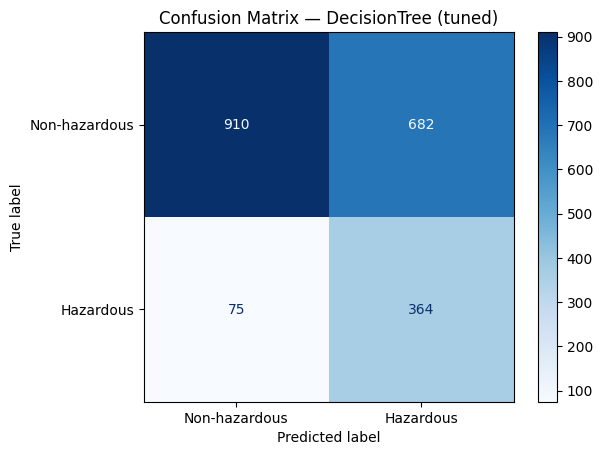


>>> Tuning RandomForest ...
Fitting 5 folds for each of 648 candidates, totalling 3240 fits

Best CV recall: 0.680
Best params: {'feat_selection__max_features': None, 'feat_selection__threshold': 'mean', 'model__class_weight': 'balanced_subsample', 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 500}

Test classification report:
              precision    recall  f1-score   support

           0      0.894     0.729     0.803      1592
           1      0.411     0.686     0.514       439

    accuracy                          0.719      2031
   macro avg      0.652     0.707     0.658      2031
weighted avg      0.789     0.719     0.740      2031

TN:1160 FP:432 FN:138 TP:301

Best CV recall: 0.680
Best params: {'feat_selection__max_features': None, 'feat_selection__threshold': 'mean', 'model__class_weight': 'balanced_subsample', 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__m

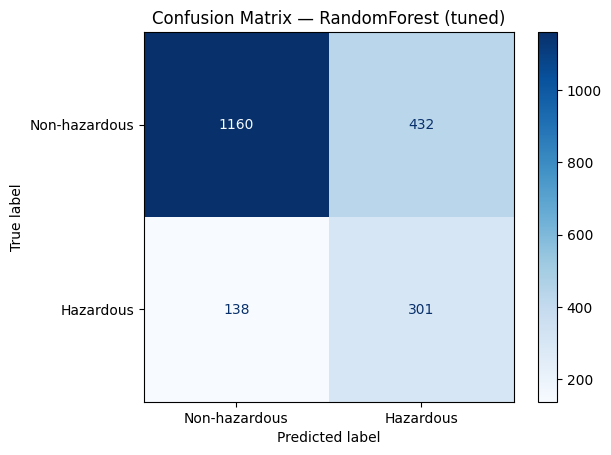


>>> Tuning ExtraTrees ...
Fitting 5 folds for each of 648 candidates, totalling 3240 fits

Best CV recall: 0.781
Best params: {'feat_selection__max_features': None, 'feat_selection__threshold': 'median', 'model__class_weight': 'balanced_subsample', 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 500}

Test classification report:
              precision    recall  f1-score   support

           0      0.918     0.722     0.808      1592
           1      0.432     0.765     0.552       439

    accuracy                          0.732      2031
   macro avg      0.675     0.744     0.680      2031
weighted avg      0.813     0.732     0.753      2031

TN:1150 FP:442 FN:103 TP:336

Best CV recall: 0.781
Best params: {'feat_selection__max_features': None, 'feat_selection__threshold': 'median', 'model__class_weight': 'balanced_subsample', 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model_

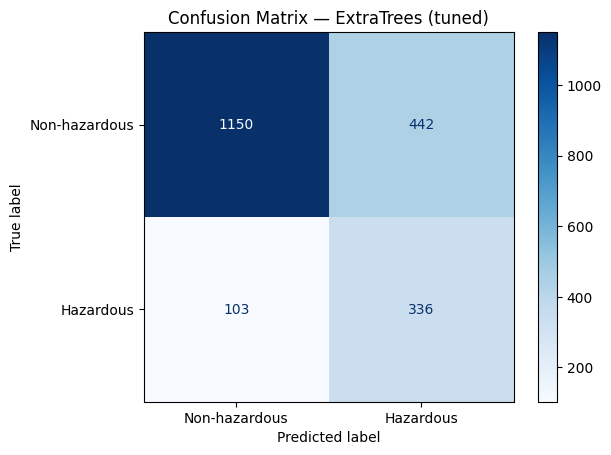

          model  cv_best_recall  test_recall  test_precision   test_f1  \
0  DecisionTree        0.821814     0.829157        0.347992  0.490236   
2    ExtraTrees        0.780858     0.765376        0.431877  0.552177   
1  RandomForest        0.680498     0.685649        0.410641  0.513652   

   test_pr_auc  test_roc_auc  test_acc  \
0     0.440273      0.765481  0.627277   
2     0.573216      0.830794  0.731659   
1     0.475908      0.778472  0.719350   

                                         best_params  
0  {'feat_selection__max_features': None, 'feat_s...  
2  {'feat_selection__max_features': None, 'feat_s...  
1  {'feat_selection__max_features': None, 'feat_s...  


In [15]:
##Caution Long Runtimes - scroll down for reduced parameter grids for faster runtimes (commented out)

# === Step 3: GridSearchCV tuning for tree models (refit on Recall) ===
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Re-define candidates (same as before)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}
#Caution Long runtimes ahead!
# Parameter grids per model (tree-friendly; adjust to taste)
param_grids = {
    "DecisionTree": {
        "feat_selection__threshold": ["median", "mean", -np.inf],   # -inf => keep all
        "feat_selection__max_features": [None, 10, 20],
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [None, 8, 16, 24],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 5],
        "model__class_weight": ["balanced", None],
    },
    "RandomForest": {
        "feat_selection__threshold": ["median", "mean", -np.inf],
        "feat_selection__max_features": [None, 15, 25],
        "model__n_estimators": [300, 500],
        "model__max_depth": [None, 12, 24],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt", "log2", None],
        "model__class_weight": ["balanced_subsample"],
    },
    "ExtraTrees": {
        "feat_selection__threshold": ["median", "mean", -np.inf],
        "feat_selection__max_features": [None, 15, 25],
        "model__n_estimators": [300, 500],
        "model__max_depth": [None, 12, 24],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt", "log2", None],
        "model__class_weight": ["balanced_subsample"],
    },
}
##Alternative more minimal grids for faster runtimes
# param_grids = {
#     "DecisionTree": {
#         "feat_selection__threshold": ["median", -np.inf],   # -inf => keep all
#         "feat_selection__max_features": [None, 15],
#         "model__criterion": ["gini", "entropy"],
#         "model__max_depth": [None, 12],
#         "model__min_samples_split": [2, 5],
#         "model__min_samples_leaf": [1, 2],
#         "model__class_weight": ["balanced"],
#     },
#     "RandomForest": {
#         "feat_selection__threshold": ["median", -np.inf],
#         "feat_selection__max_features": [None, 20],
#         "model__n_estimators": [200, 400],
#         "model__max_depth": [None, 16],
#         "model__min_samples_split": [2, 5],
#         "model__min_samples_leaf": [1, 2],
#         "model__max_features": ["sqrt", "log2"],
#         "model__class_weight": ["balanced_subsample"],
#     },
#     "ExtraTrees": {
#         "feat_selection__threshold": ["median", -np.inf],
#         "feat_selection__max_features": [None, 20],
#         "model__n_estimators": [200, 400],
#         "model__max_depth": [None, 16],
#         "model__min_samples_split": [2, 5],
#         "model__min_samples_leaf": [1, 2],
#         "model__max_features": ["sqrt", "log2"],
#         "model__class_weight": ["balanced_subsample"],
#     },
# }

# Grid search loop
tuned_results = []
best_pipes = {}

for name, base_model in candidates.items():
    print(f"\n>>> Tuning {name} ...")
    pipe = PipelineOptimization(base_model)
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring=scoring,
        refit="recall",          # safety-first: choose the model with best CV recall
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)

    # Keep best pipeline
    best_pipes[name] = grid.best_estimator_

    # Evaluate on test set
    y_pred = grid.best_estimator_.predict(X_test)
    y_prob = (
        grid.best_estimator_.predict_proba(X_test)[:, 1]
        if hasattr(grid.best_estimator_, "predict_proba")
        else None
    )
    # Evaluate metrics
    acc = accuracy_score(y_test, y_pred)
    rec = classification_report(y_test, y_pred, output_dict=True)["1"]["recall"]
    prec = classification_report(y_test, y_pred, output_dict=True)["1"]["precision"]
    f1 = classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"]
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    pr  = average_precision_score(y_test, y_prob) if y_prob is not None else np.nan

    # Store results
    tuned_results.append({
        "model": name,
        "cv_best_recall": grid.best_score_,
        "test_acc": acc,
        "test_recall": rec,
        "test_precision": prec,
        "test_f1": f1,
        "test_roc_auc": roc,
        "test_pr_auc": pr,
        "best_params": grid.best_params_
    })
    # Print summary
    print(f"\nBest CV recall: {grid.best_score_:.3f}")
    print("Best params:", grid.best_params_)
    print("\nTest classification report:")
    print(classification_report(y_test, y_pred, digits=3))

    # Confusion matrix (absolute counts)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"TN:{tn} FP:{fp} FN:{fn} TP:{tp}")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-hazardous", "Hazardous"])
    disp.plot(cmap="Blues", values_format="d")
    disp.ax_.set_title(f"Confusion Matrix — {name} (tuned)")
    plt.show()

# Summary table of tuned models (sorted by test_recall, then PR AUC)
tuned_df = pd.DataFrame(tuned_results).sort_values(
    by=["test_recall", "test_pr_auc", "test_roc_auc"], ascending=False
)
print(tuned_df[["model","cv_best_recall","test_recall","test_precision","test_f1","test_pr_auc","test_roc_auc","test_acc","best_params"]])


Now we have our ranking, we can see that Decision Tree had the best recall scores, though performed worse for other metrics. 
* All 3 models had reasonably good roc_auc scores showing they were more tuned to choose true positive results over false positive results
* Decision tree was best at predicting true positives it also had the highest rate for false positives also. 
* Erring on the side of caution would perhaps be better in this case - i.e. predicting hazardous asteroids

#### --- Best 5 Models & Parameters ---

In [16]:
# Ensure pandas display is readable
pd.set_option('display.max_colwidth', None)

# Show top 3 models & parameters
print("\nTop 3 model–parameter combinations:")
tuned_df[["model","cv_best_recall","test_recall","test_precision","test_f1","test_pr_auc","test_roc_auc","test_acc","best_params"]].head().T


Top 3 model–parameter combinations:


,0,2,1
model,DecisionTree,ExtraTrees,RandomForest
cv_best_recall,0.821814,0.780858,0.680498
test_recall,0.829157,0.765376,0.685649
test_precision,0.347992,0.431877,0.410641
test_f1,0.490236,0.552177,0.513652
test_pr_auc,0.440273,0.573216,0.475908
test_roc_auc,0.765481,0.830794,0.778472
test_acc,0.627277,0.731659,0.71935
best_params,"{'feat_selection__max_features': None, 'feat_selection__threshold': 'mean', 'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 8, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10}","{'feat_selection__max_features': None, 'feat_selection__threshold': 'median', 'model__class_weight': 'balanced_subsample', 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 500}","{'feat_selection__max_features': None, 'feat_selection__threshold': 'mean', 'model__class_weight': 'balanced_subsample', 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 500}"


Next we can grab our best model & param combination for our pipeline and look at which features were selected to train our model.

In [17]:
# Next we can grab our best model & param combination
best_model_name = tuned_df.iloc[0]["model"]
best_params = tuned_df.iloc[0]["best_params"]
best_model_name, best_params

('DecisionTree',
 {'feat_selection__max_features': None,
  'feat_selection__threshold': 'mean',
  'model__class_weight': 'balanced',
  'model__criterion': 'entropy',
  'model__max_depth': 8,
  'model__min_samples_leaf': 2,
  'model__min_samples_split': 10})

In [18]:
#save our results dataframe to a csv file
tuned_df.to_csv('Data/Processed/tuned_model_results.csv', index=False)

#### Feature Importance

Next we test which features have the most impact on the model and were selected to train the model.

In [21]:
# Extract selector and model from pipeline
pipe = best_pipes[best_model_name]
selector = pipe.named_steps["feat_selection"]
model = pipe.named_steps["model"]

# Get feature mask (True = feature kept)
mask = selector.get_support()

# Match to your original training columns
selected_features = X_train.columns[mask]

print("Selected features used in final model:")
for i, feat in enumerate(selected_features, start=1):
    print(f"{i}. {feat}")

Selected features used in final model:
1. miss_distance_mean
2. relative_velocity_mean
3. absolute_magnitude_mean


In [22]:
# Create aligned importance list
importances = pd.Series(model.feature_importances_, index=selected_features).sort_values(ascending=False)

print("\nFeature importances (aligned with selected features):")
print(importances)


Feature importances (aligned with selected features):
relative_velocity_mean     0.383938
miss_distance_mean         0.347032
absolute_magnitude_mean    0.269030
dtype: float64


So our model trained on these 4 features, with velocity and miss distance the most important factors - giving validation to some of our hypotheses:
* A combination of **size**, **speed**, and **miss distance** can effectively predict hazard status.
* **Closer approaches to Earth** (smaller miss distances) are associated with a higher likelihood of hazard classification.
* **Larger asteroids** (greater estimated diameters) are more likely to be classified as hazardous.
- Note: was listed in first run, but not second (4th most important)
* **Higher relative velocities** correlate with greater hazard potential (due to increased impact energy).
* **Absolute magnitude** (brightness) inversely correlates with hazard level — brighter (larger) objects are more likely to be hazardous. 

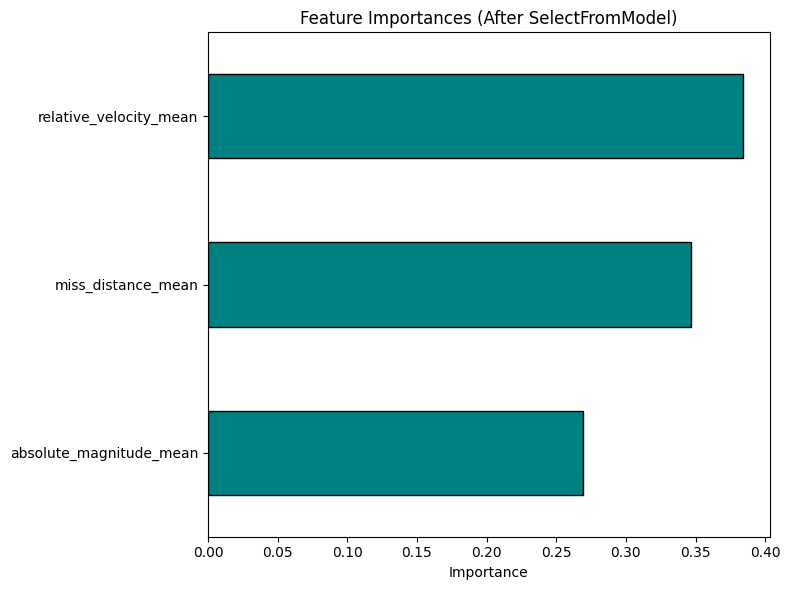

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
importances.sort_values().plot(kind="barh", color="teal", edgecolor="black")
plt.title("Feature Importances (After SelectFromModel)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [24]:
## create reduced dataframe with random selection (10%) only the selected features and target
## For easier plotting
df_reduced = df_tree_model[selected_features.tolist() + ["hazardous_enc"]].sample(frac=0.05, random_state=42)

In [26]:
# Parallel coordinates plot with Plotly

fig = px.parallel_coordinates(
    df_reduced,
    dimensions=[
        #"est_diameter_mean", -commented out as not selected in final model
        "miss_distance_mean",
        "relative_velocity_mean",
        "absolute_magnitude_mean"
    ],
    color="hazardous_enc",
    #use color safe colours
    color_continuous_scale=["teal", "Orange"],
    labels={
        #"est_diameter_mean": "Diameter (km)", -commented out as not selected in final model
        "miss_distance_mean": "Miss Distance (km)",
        "relative_velocity_mean": "Velocity (km/s)",
        #invert the label to show that lower magnitude means brighter/larger
        "absolute_magnitude_mean": "Abs Magnitude (H) - Lower is Brighter",
    },
    title="Parallel Coordinates — Comparing Key Features by Hazard Status"
)

fig.update_layout(
    width=900, height=600,
    template="plotly_white"
)
fig.show()


To view in github "Data/images/Hazard_features_parallel_run2.png"

Parallel plot shows the connections between the most important features selected by our model and their patterns for hazardous/ hazardous asteroids. This plot uses a reduced randomised sample of our dataset for clarity.


In [30]:
#create inverted scale for absolute magnitude for easier interpretability
df_reduced['inv_absolute_magnitude_mean'] = df_reduced['absolute_magnitude_mean'].max() - df_reduced['absolute_magnitude_mean']

In [ ]:
## Scatter plot with Plotly - showing the relationship between miss distance and relative velocity, colored by hazardous status. size by absolute magnitude
fig = px.scatter(
    df_reduced,
    x="miss_distance_mean",
    y="relative_velocity_mean",
    color="hazardous_enc",
    size="absolute_magnitude_mean",
    color_discrete_map={0: "Teal", 1: "Orange"},
    labels={
        "miss_distance_mean": "Miss Distance (km)",
        "relative_velocity_mean": "Relative Velocity (km/s)",
        "absolute_magnitude_mean": "Absolute Magnitude (H) - Size of Point ~ Brightness"
    },
    title="Miss Distance vs Relative Velocity, Sized by Absolute Magnitude"
)
fig.update_layout(
    width=900, height=600,
    template="plotly_white"
)
fig.show()


Scatterplot showing two most important features, coloured by hazard status (magnitude is visible on mouse-over). The plot shows a clear band of hazardous objects from very close passes to around 50m km and increasing hazard status with velocity. (using reduced randomised data for clarity)

# Conclusions

- Built a reproducible ML pipeline from `features_model.csv` that filters out sub-140 m objects, creates binned classes (diameter/proximity/velocity/brightness/observations), and saves a model-ready dataset.
- Trained baseline tree-based classifiers (Random Forest / related ensembles) on a compact feature set with ordinal encoding; train/test split used a fixed seed and shows reasonable class balance for evaluation.
- A model comparison table and cross-validated metrics were generated in the notebook — consult that table for exact ROC-AUC / PR-AUC / confusion-matrix values for each candidate.
- Feature-importance analyses  identify diameter and brightness-related measures, plus proximity/velocity, as key predictors consistent with EDA findings.
- These findings validate the physical hypotheses outlined in README.md
- Important caveats: dataset was deliberately reduced (dropped very small asteroids) which limits the models’ applicability to the original population; lack of orbital data constrains real-world risk inference.

#### Potentail Next Steps 

* Run tests with logistic regression algorithms
* Re run with different combinations (features & params)
* Test with different datasets (Preferably containing orbital data)